In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [3]:
API_KEY = "7b583cb791644f08b0dc0b80b7127a36"

BASE_URL = "https://api.football-data.org/v4"
HEADERS = {"X-Auth-Token": API_KEY}
SEASON = 2023

LEAGUES = {
    "PL": "EPL (잉글랜드)",
    "PD": "라리가 (스페인)",
}

print(f"✅ 설정 완료 | 시즌: {SEASON}-{SEASON+1}")

✅ 설정 완료 | 시즌: 2023-2024


In [4]:
def test_connection():
    url = f"{BASE_URL}/competitions/PL"
    res = requests.get(url, headers=HEADERS)
    
    if res.status_code == 200:
        data = res.json()
        print(f"✅ API 연결 성공!")
        print(f"   리그: {data['name']}")
        print(f"   시즌: {data['currentSeason']['startDate']} ~ {data['currentSeason']['endDate']}")
    elif res.status_code == 403:
        print("❌ API 키를 다시 확인해주세요")
    else:
        print(f"❌ 오류: {res.status_code}")

test_connection()

✅ API 연결 성공!
   리그: Premier League
   시즌: 2025-08-15 ~ 2026-05-24


In [5]:
def fetch_matches(league_code, season):
    url = f"{BASE_URL}/competitions/{league_code}/matches"
    params = {"season": season, "status": "FINISHED"}
    
    print(f"  [{LEAGUES[league_code]}] 데이터 수집 중...")
    res = requests.get(url, headers=HEADERS, params=params)
    
    if res.status_code != 200:
        print(f"  ❌ 오류: {res.status_code}")
        return pd.DataFrame()
    
    matches = res.json().get("matches", [])
    print(f"  ✅ {len(matches)}경기 수집 완료")
    
    rows = []
    for m in matches:
        ft = m["score"]["fullTime"]
        rows.append({
            "match_id":   m["id"],
            "date":       m["utcDate"][:10],
            "league":     league_code,
            "home_team":  m["homeTeam"]["name"],
            "away_team":  m["awayTeam"]["name"],
            "home_goals": ft.get("home"),
            "away_goals": ft.get("away"),
            "matchday":   m.get("matchday"),
        })
    
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    
    def get_result(row):
        if row["home_goals"] > row["away_goals"]:   return "H"
        elif row["home_goals"] < row["away_goals"]: return "A"
        else:                                        return "D"
    
    df["result"] = df.apply(get_result, axis=1)
    df = df.sort_values("date").reset_index(drop=True)
    return df

In [6]:
all_dfs = []

for code in LEAGUES:
    df = fetch_matches(code, SEASON)
    if not df.empty:
        all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)

print(f"\n✅ 전체 수집 완료")
print(f"   총 경기 수: {len(df_raw)}")
print(f"   기간: {df_raw['date'].min().date()} ~ {df_raw['date'].max().date()}")
print(f"\n결과 분포:")
print(df_raw['result'].value_counts())
df_raw.head()

  [EPL (잉글랜드)] 데이터 수집 중...
  ✅ 380경기 수집 완료
  [라리가 (스페인)] 데이터 수집 중...
  ✅ 380경기 수집 완료

✅ 전체 수집 완료
   총 경기 수: 760
   기간: 2023-08-11 ~ 2024-05-26

결과 분포:
result
H    342
A    229
D    189
Name: count, dtype: int64


,match_id,date,league,home_team,away_team,home_goals,away_goals,matchday,result
0,435943,2023-08-11,PL,Burnley FC,Manchester City FC,0,3,1,A
1,435944,2023-08-12,PL,Arsenal FC,Nottingham Forest FC,2,1,1,H
2,435945,2023-08-12,PL,AFC Bournemouth,West Ham United FC,1,1,1,D
3,435946,2023-08-12,PL,Brighton & Hove Albion FC,Luton Town FC,4,1,1,H
4,435947,2023-08-12,PL,Everton FC,Fulham FC,0,1,1,A


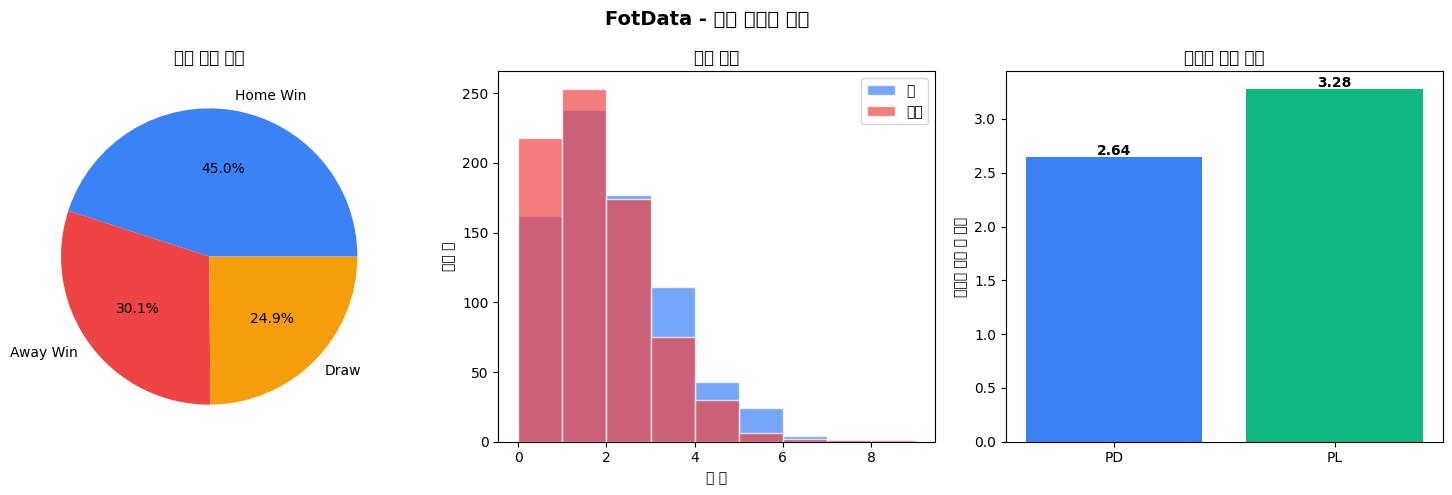

✅ 그래프 저장 완료


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("FotData - 기본 데이터 분석", fontsize=14, fontweight='bold')

result_counts = df_raw['result'].value_counts()
axes[0].pie(
    result_counts.values,
    labels=['Home Win', 'Away Win', 'Draw'],
    autopct='%1.1f%%',
    colors=['#3B82F6', '#EF4444', '#F59E0B']
)
axes[0].set_title("경기 결과 분포")

axes[1].hist(df_raw['home_goals'].dropna(), bins=range(0,10),
             alpha=0.7, color='#3B82F6', label='홈', edgecolor='white')
axes[1].hist(df_raw['away_goals'].dropna(), bins=range(0,10),
             alpha=0.7, color='#EF4444', label='원정', edgecolor='white')
axes[1].set_xlabel("골 수")
axes[1].set_ylabel("경기 수")
axes[1].set_title("득점 분포")
axes[1].legend()

df_raw['total_goals'] = df_raw['home_goals'] + df_raw['away_goals']
league_avg = df_raw.groupby('league')['total_goals'].mean()
bars = axes[2].bar(league_avg.index, league_avg.values,
                   color=['#3B82F6', '#10B981'])
axes[2].set_ylabel("경기당 평균 총 득점")
axes[2].set_title("리그별 평균 득점")
for bar, val in zip(bars, league_avg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fotdata_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 그래프 저장 완료")

In [8]:
output = f"fotdata_raw_{SEASON}.csv"
df_raw.to_csv(output, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {output}")
print(f"   행: {len(df_raw)}  열: {len(df_raw.columns)}")
print(f"   컬럼: {list(df_raw.columns)}")

✅ 저장 완료: fotdata_raw_2023.csv
   행: 760  열: 10
   컬럼: ['match_id', 'date', 'league', 'home_team', 'away_team', 'home_goals', 'away_goals', 'matchday', 'result', 'total_goals']


In [9]:
def calculate_team_stats(df):
    teams = pd.concat([df['home_team'], df['away_team']]).unique()
    stats = []
    
    for team in teams:
        home = df[df['home_team'] == team]
        away = df[df['away_team'] == team]
        
        games = len(home) + len(away)
        goals_scored = home['home_goals'].sum() + away['away_goals'].sum()
        goals_conceded = home['away_goals'].sum() + away['home_goals'].sum()
        
        wins = len(home[home['result'] == 'H']) + len(away[away['result'] == 'A'])
        draws = len(home[home['result'] == 'D']) + len(away[away['result'] == 'D'])
        losses = games - wins - draws
        points = wins * 3 + draws
        
        stats.append({
            "team":             team,
            "games":            games,
            "wins":             wins,
            "draws":            draws,
            "losses":           losses,
            "points":           points,
            "goals_scored":     goals_scored,
            "goals_conceded":   goals_conceded,
            "goal_diff":        goals_scored - goals_conceded,
            "attack_strength":  round(goals_scored / games, 3),   # 경기당 득점
            "defense_strength": round(goals_conceded / games, 3), # 경기당 실점
            "win_rate":         round(wins / games, 3),
        })
    
    return pd.DataFrame(stats).sort_values("points", ascending=False).reset_index(drop=True)

df_stats = calculate_team_stats(df_raw)
print("✅ 팀 스탯 계산 완료")
df_stats.head(10)

✅ 팀 스탯 계산 완료


,team,games,wins,draws,losses,points,goals_scored,goals_conceded,goal_diff,attack_strength,defense_strength,win_rate
0,Real Madrid CF,38,29,8,1,95,87,26,61,2.289,0.684,0.763
1,Manchester City FC,38,28,7,3,91,96,34,62,2.526,0.895,0.737
2,Arsenal FC,38,28,5,5,89,91,29,62,2.395,0.763,0.737
3,FC Barcelona,38,26,7,5,85,79,44,35,2.079,1.158,0.684
4,Liverpool FC,38,24,10,4,82,86,41,45,2.263,1.079,0.632
5,Girona FC,38,25,6,7,81,85,46,39,2.237,1.211,0.658
6,Club Atlético de Madrid,38,24,4,10,76,70,43,27,1.842,1.132,0.632
7,Aston Villa FC,38,20,8,10,68,76,61,15,2.000,1.605,0.526
8,Athletic Club,38,19,11,8,68,61,37,24,1.605,0.974,0.500
9,Tottenham Hotspur FC,38,20,6,12,66,74,61,13,1.947,1.605,0.526


In [10]:
def get_recent_form(df, team, before_date, n=5):
    """특정 날짜 이전 최근 n경기 승점 합계"""
    team_matches = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < before_date)
    ].tail(n)
    
    points = 0
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            if row['result'] == 'H': points += 3
            elif row['result'] == 'D': points += 1
        else:
            if row['result'] == 'A': points += 3
            elif row['result'] == 'D': points += 1
    return points

# 테스트
test_team = df_raw['home_team'].iloc[50]
test_date = df_raw['date'].iloc[50]
form = get_recent_form(df_raw, test_team, test_date)
print(f"✅ 폼 계산 완료")
print(f"   {test_team}의 {test_date.date()} 이전 최근 5경기 승점: {form}점")

✅ 폼 계산 완료
   Luton Town FC의 2023-09-23 이전 최근 5경기 승점: 0점


In [11]:
def build_features(df):
    rows = []
    
    for _, match in df.iterrows():
        home = match['home_team']
        away = match['away_team']
        date = match['date']
        
        # 최근 5경기 폼
        home_form = get_recent_form(df, home, date, n=5)
        away_form = get_recent_form(df, away, date, n=5)
        
        # 팀 전체 스탯
        h_stats = df_stats[df_stats['team'] == home]
        a_stats = df_stats[df_stats['team'] == away]
        
        if h_stats.empty or a_stats.empty:
            continue
            
        h = h_stats.iloc[0]
        a = a_stats.iloc[0]
        
        rows.append({
            "match_id":           match['match_id'],
            "date":               date,
            "league":             match['league'],
            "home_team":          home,
            "away_team":          away,
            
            # 공격력 / 수비력
            "home_attack":        h['attack_strength'],
            "away_attack":        a['attack_strength'],
            "home_defense":       h['defense_strength'],
            "away_defense":       a['defense_strength'],
            
            # 최근 폼
            "home_form":          home_form,
            "away_form":          away_form,
            "form_diff":          home_form - away_form,
            
            # 승률
            "home_win_rate":      h['win_rate'],
            "away_win_rate":      a['win_rate'],
            "win_rate_diff":      h['win_rate'] - a['win_rate'],
            
            # 득실차
            "home_goal_diff":     h['goal_diff'],
            "away_goal_diff":     a['goal_diff'],
            
            # 결과 (label)
            "result":             match['result'],
        })
    
    return pd.DataFrame(rows)

print("Feature 생성 중... (약 10~20초 소요)")
df_features = build_features(df_raw)
print(f"✅ Feature 생성 완료: {len(df_features)}경기, {len(df_features.columns)}개 컬럼")
df_features.head()

Feature 생성 중... (약 10~20초 소요)
✅ Feature 생성 완료: 760경기, 18개 컬럼


,match_id,date,league,home_team,away_team,home_attack,away_attack,home_defense,away_defense,home_form,away_form,form_diff,home_win_rate,away_win_rate,win_rate_diff,home_goal_diff,away_goal_diff,result
0,435943,2023-08-11,PL,Burnley FC,Manchester City FC,1.079,2.526,2.053,0.895,0,0,0,0.132,0.737,-0.605,-37,62,A
1,435944,2023-08-12,PL,Arsenal FC,Nottingham Forest FC,2.395,1.289,0.763,1.763,0,0,0,0.737,0.237,0.500,62,-18,H
2,435945,2023-08-12,PL,AFC Bournemouth,West Ham United FC,1.421,1.579,1.763,1.947,0,0,0,0.342,0.368,-0.026,-13,-14,D
3,435946,2023-08-12,PL,Brighton & Hove Albion FC,Luton Town FC,1.447,1.368,1.632,2.237,0,0,0,0.316,0.158,0.158,-7,-33,H
4,435947,2023-08-12,PL,Everton FC,Fulham FC,1.053,1.447,1.342,1.605,0,0,0,0.342,0.342,0.000,-11,-6,A


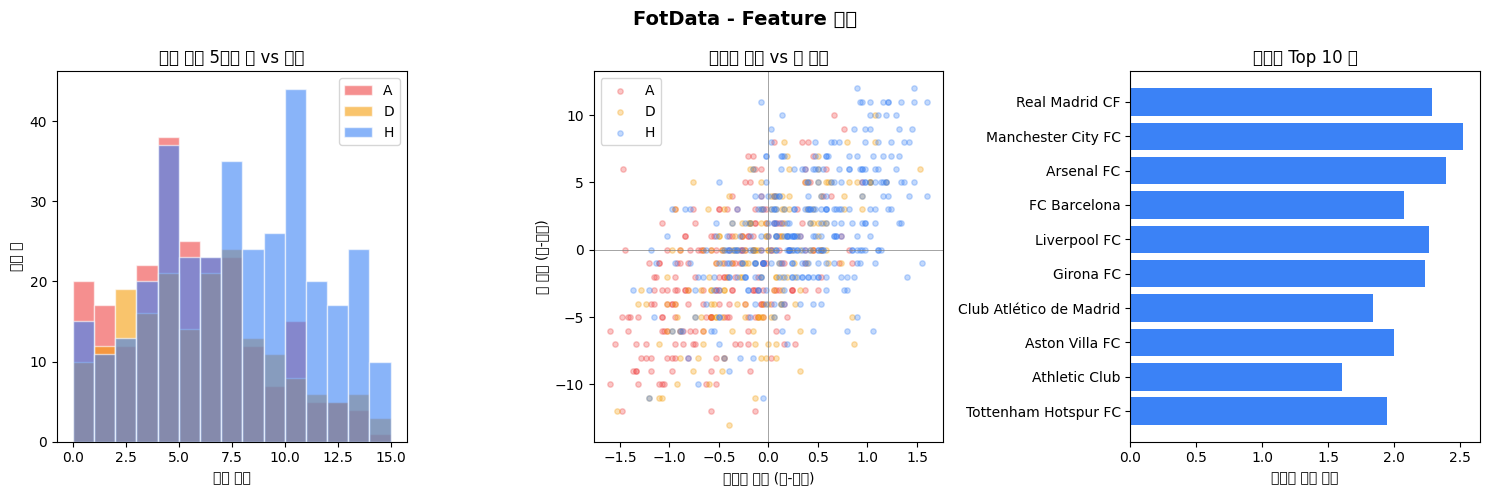

✅ Feature 시각화 완료


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("FotData - Feature 분석", fontsize=14, fontweight='bold')

colors = {'H': '#3B82F6', 'D': '#F59E0B', 'A': '#EF4444'}

# 1) 홈 폼 vs 결과
for result, group in df_features.groupby('result'):
    axes[0].hist(group['home_form'], alpha=0.6, label=result,
                 color=colors[result], bins=range(0, 16), edgecolor='white')
axes[0].set_title("홈팀 최근 5경기 폼 vs 결과")
axes[0].set_xlabel("승점 합계")
axes[0].set_ylabel("경기 수")
axes[0].legend()

# 2) 공격력 차이 vs 결과
df_features['attack_diff'] = df_features['home_attack'] - df_features['away_attack']
for result, group in df_features.groupby('result'):
    axes[1].scatter(group['attack_diff'], group['form_diff'],
                    alpha=0.3, label=result, color=colors[result], s=15)
axes[1].set_title("공격력 차이 vs 폼 차이")
axes[1].set_xlabel("공격력 차이 (홈-원정)")
axes[1].set_ylabel("폼 차이 (홈-원정)")
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)

# 3) 팀별 공격력 Top 10
top10 = df_stats.head(10)
axes[2].barh(top10['team'], top10['attack_strength'], color='#3B82F6')
axes[2].set_title("공격력 Top 10 팀")
axes[2].set_xlabel("경기당 평균 득점")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('fotdata_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature 시각화 완료")

In [13]:
df_features.to_csv('fotdata_features_2023.csv', index=False, encoding='utf-8-sig')
print("✅ 저장 완료: fotdata_features_2023.csv")
print(f"   Feature 목록: {list(df_features.columns)}")

✅ 저장 완료: fotdata_features_2023.csv
   Feature 목록: ['match_id', 'date', 'league', 'home_team', 'away_team', 'home_attack', 'away_attack', 'home_defense', 'away_defense', 'home_form', 'away_form', 'form_diff', 'home_win_rate', 'away_win_rate', 'win_rate_diff', 'home_goal_diff', 'away_goal_diff', 'result', 'attack_diff']


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Feature 선택
FEATURES = [
    'home_attack', 'away_attack',
    'home_defense', 'away_defense',
    'home_form', 'away_form', 'form_diff',
    'home_win_rate', 'away_win_rate', 'win_rate_diff',
    'home_goal_diff', 'away_goal_diff',
    'attack_diff'
]

X = df_features[FEATURES]
y = df_features['result']

# 결측치 제거
X = X.dropna()
y = y[X.index]

print(f"✅ 학습 데이터 준비 완료")
print(f"   샘플 수: {len(X)}")
print(f"   Feature 수: {len(FEATURES)}")
print(f"   클래스 분포:\n{y.value_counts()}")

✅ 학습 데이터 준비 완료
   샘플 수: 760
   Feature 수: 13
   클래스 분포:
result
H    342
A    229
D    189
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ 데이터 분리 완료")
print(f"   학습 데이터: {len(X_train)}경기")
print(f"   테스트 데이터: {len(X_test)}경기")

✅ 데이터 분리 완료
   학습 데이터: 608경기
   테스트 데이터: 152경기


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    # 로지스틱 회귀는 스케일링 적용
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "accuracy": acc, "y_pred": y_pred}
    
    print(f"\n{'='*40}")
    print(f"📊 {name}")
    print(f"   정확도: {acc:.1%}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win'])}")

print("✅ 모델 학습 완료")


📊 Logistic Regression
   정확도: 58.6%

              precision    recall  f1-score   support

    Away Win       0.57      0.65      0.61        46
        Draw       0.47      0.18      0.26        38
    Home Win       0.62      0.76      0.68        68

    accuracy                           0.59       152
   macro avg       0.55      0.53      0.52       152
weighted avg       0.56      0.59      0.56       152


📊 Random Forest
   정확도: 52.6%

              precision    recall  f1-score   support

    Away Win       0.54      0.57      0.55        46
        Draw       0.28      0.18      0.22        38
    Home Win       0.59      0.69      0.64        68

    accuracy                           0.53       152
   macro avg       0.47      0.48      0.47       152
weighted avg       0.50      0.53      0.51       152

✅ 모델 학습 완료


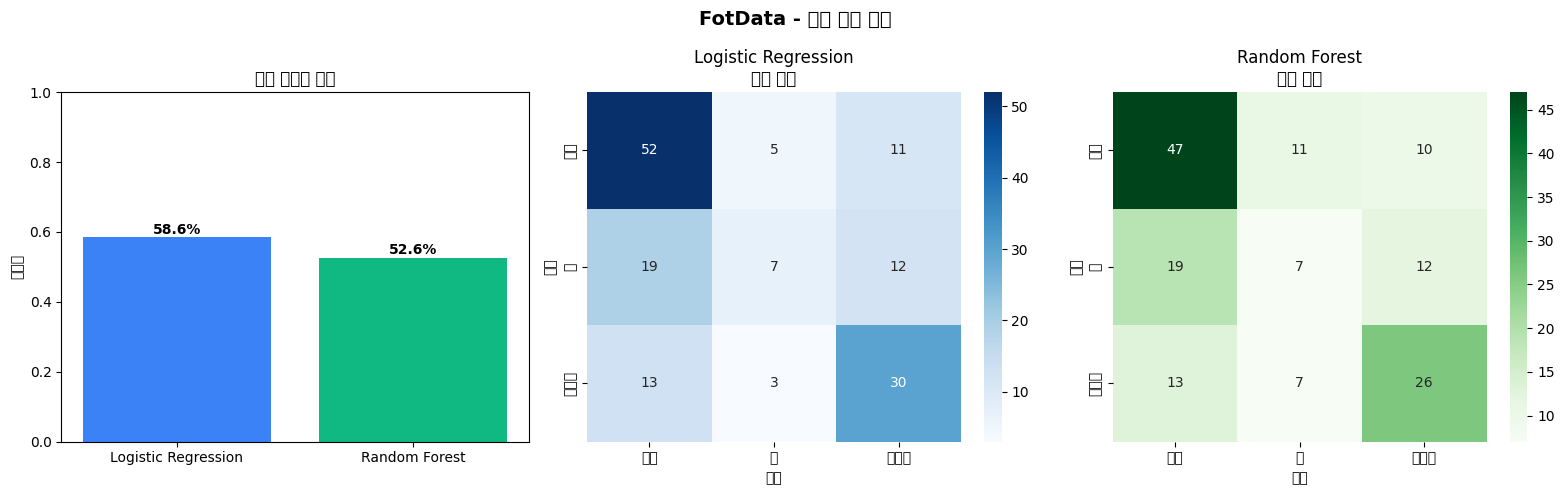

✅ 시각화 완료


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("FotData - 모델 성능 비교", fontsize=14, fontweight='bold')

# 1) 정확도 비교
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = axes[0].bar(names, accs, color=['#3B82F6', '#10B981'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("정확도")
axes[0].set_title("모델 정확도 비교")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 acc + 0.01, f'{acc:.1%}', ha='center', fontweight='bold')

# 2) Logistic Regression 혼동 행렬
import seaborn as sns
cm1 = confusion_matrix(y_test, results['Logistic Regression']['y_pred'], labels=['H','D','A'])
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[1],
            xticklabels=['홈승','무','원정승'],
            yticklabels=['홈승','무','원정승'],
            cmap='Blues')
axes[1].set_title("Logistic Regression\n혼동 행렬")
axes[1].set_ylabel("실제")
axes[1].set_xlabel("예측")

# 3) Random Forest 혼동 행렬
cm2 = confusion_matrix(y_test, results['Random Forest']['y_pred'], labels=['H','D','A'])
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[2],
            xticklabels=['홈승','무','원정승'],
            yticklabels=['홈승','무','원정승'],
            cmap='Greens')
axes[2].set_title("Random Forest\n혼동 행렬")
axes[2].set_ylabel("실제")
axes[2].set_xlabel("예측")

plt.tight_layout()
plt.savefig('fotdata_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 완료")

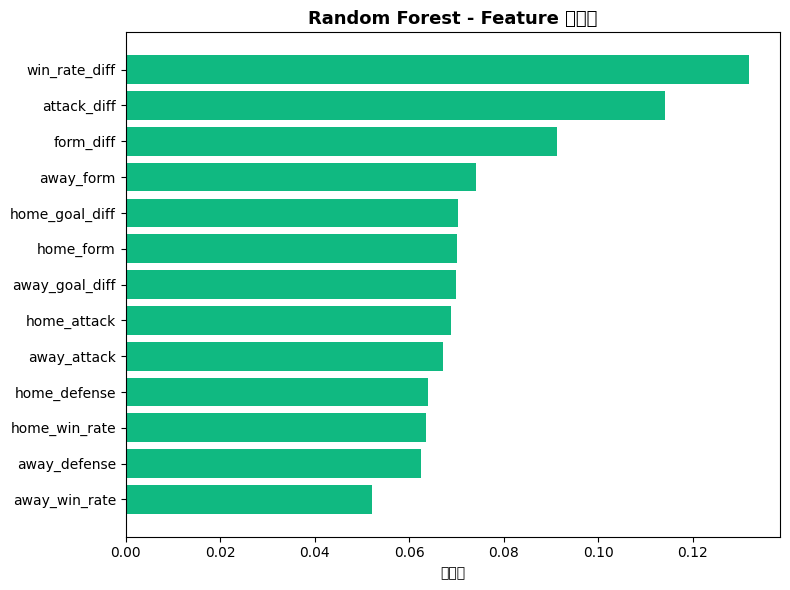

✅ Feature 중요도 완료


In [18]:
importances = results['Random Forest']['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='#10B981')
plt.title("Random Forest - Feature 중요도", fontsize=13, fontweight='bold')
plt.xlabel("중요도")
plt.tight_layout()
plt.savefig('fotdata_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature 중요도 완료")

In [19]:
def predict_match(home_team, away_team):
    """두 팀을 입력하면 승/무/패 확률을 반환합니다"""
    
    h = df_stats[df_stats['team'] == home_team]
    a = df_stats[df_stats['team'] == away_team]
    
    if h.empty:
        print(f"❌ '{home_team}' 팀을 찾을 수 없습니다")
        print(f"   사용 가능한 팀: {list(df_stats['team'])}")
        return
    if a.empty:
        print(f"❌ '{away_team}' 팀을 찾을 수 없습니다")
        return
    
    h, a = h.iloc[0], a.iloc[0]
    
    input_data = pd.DataFrame([{
        'home_attack':    h['attack_strength'],
        'away_attack':    a['attack_strength'],
        'home_defense':   h['defense_strength'],
        'away_defense':   a['defense_strength'],
        'home_form':      h['win_rate'] * 15,
        'away_form':      a['win_rate'] * 15,
        'form_diff':      (h['win_rate'] - a['win_rate']) * 15,
        'home_win_rate':  h['win_rate'],
        'away_win_rate':  a['win_rate'],
        'win_rate_diff':  h['win_rate'] - a['win_rate'],
        'home_goal_diff': h['goal_diff'],
        'away_goal_diff': a['goal_diff'],
        'attack_diff':    h['attack_strength'] - a['attack_strength'],
    }])
    
    model = results['Random Forest']['model']
    proba = model.predict_proba(input_data)[0]
    classes = model.classes_
    
    proba_dict = dict(zip(classes, proba))
    
    print(f"\n{'='*45}")
    print(f"  ⚽ {home_team}")
    print(f"      vs")
    print(f"  ⚽ {away_team}")
    print(f"{'='*45}")
    print(f"  🏠 홈승:   {proba_dict.get('H', 0):.1%}")
    print(f"  🤝 무승부: {proba_dict.get('D', 0):.1%}")
    print(f"  ✈️  원정승: {proba_dict.get('A', 0):.1%}")
    print(f"{'='*45}")

# 테스트 예측
predict_match("Manchester City FC", "Arsenal FC")


  ⚽ Manchester City FC
      vs
  ⚽ Arsenal FC
  🏠 홈승:   17.0%
  🤝 무승부: 78.0%
  ✈️  원정승: 5.0%


In [20]:
def get_recent_form_for_predict(df, team, n=5):
    """가장 최근 n경기 폼을 계산 (날짜 제한 없음)"""
    team_matches = df[
        (df['home_team'] == team) | (df['away_team'] == team)
    ].tail(n)
    
    points = 0
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            if row['result'] == 'H': points += 3
            elif row['result'] == 'D': points += 1
        else:
            if row['result'] == 'A': points += 3
            elif row['result'] == 'D': points += 1
    return points

def predict_match_v2(home_team, away_team):
    """개선된 경기 예측 함수"""
    
    h_stats = df_stats[df_stats['team'] == home_team]
    a_stats = df_stats[df_stats['team'] == away_team]
    
    if h_stats.empty:
        print(f"❌ '{home_team}' 팀을 찾을 수 없습니다")
        print(f"\n사용 가능한 팀 목록:")
        for t in sorted(df_stats['team'].tolist()):
            print(f"   {t}")
        return
    if a_stats.empty:
        print(f"❌ '{away_team}' 팀을 찾을 수 없습니다")
        return
    
    h = h_stats.iloc[0]
    a = a_stats.iloc[0]
    
    # 실제 최근 5경기 폼 계산
    home_form = get_recent_form_for_predict(df_raw, home_team, n=5)
    away_form = get_recent_form_for_predict(df_raw, away_team, n=5)
    
    input_data = pd.DataFrame([{
        'home_attack':    h['attack_strength'],
        'away_attack':    a['attack_strength'],
        'home_defense':   h['defense_strength'],
        'away_defense':   a['defense_strength'],
        'home_form':      home_form,
        'away_form':      away_form,
        'form_diff':      home_form - away_form,
        'home_win_rate':  h['win_rate'],
        'away_win_rate':  a['win_rate'],
        'win_rate_diff':  h['win_rate'] - a['win_rate'],
        'home_goal_diff': h['goal_diff'],
        'away_goal_diff': a['goal_diff'],
        'attack_diff':    h['attack_strength'] - a['attack_strength'],
    }])
    
    model = results['Random Forest']['model']
    proba = model.predict_proba(input_data)[0]
    classes = model.classes_
    proba_dict = dict(zip(classes, proba))
    
    h_prob = proba_dict.get('H', 0)
    d_prob = proba_dict.get('D', 0)
    a_prob = proba_dict.get('A', 0)
    
    # 가장 높은 확률 결과
    if h_prob == max(h_prob, d_prob, a_prob):
        predicted = f"🏠 {home_team} 승리 예측"
    elif a_prob == max(h_prob, d_prob, a_prob):
        predicted = f"✈️  {away_team} 승리 예측"
    else:
        predicted = "🤝 무승부 예측"
    
    print(f"\n{'='*48}")
    print(f"  ⚽ {home_team} (홈)")
    print(f"       vs")
    print(f"  ⚽ {away_team} (원정)")
    print(f"{'='*48}")
    print(f"  🏠 홈승:    {h_prob:.1%}  {'█' * int(h_prob * 20)}")
    print(f"  🤝 무승부:  {d_prob:.1%}  {'█' * int(d_prob * 20)}")
    print(f"  ✈️  원정승:  {a_prob:.1%}  {'█' * int(a_prob * 20)}")
    print(f"{'='*48}")
    print(f"  📊 최근 폼 | 홈: {home_form}점  원정: {away_form}점")
    print(f"  🎯 {predicted}")
    print(f"{'='*48}")

# 테스트
predict_match_v2("Manchester City FC", "Arsenal FC")


  ⚽ Manchester City FC (홈)
       vs
  ⚽ Arsenal FC (원정)
  🏠 홈승:    14.0%  ██
  🤝 무승부:  78.0%  ███████████████
  ✈️  원정승:  8.0%  █
  📊 최근 폼 | 홈: 15점  원정: 15점
  🎯 🤝 무승부 예측


In [21]:
# XGBoost 설치 (처음 한 번만)
import subprocess
subprocess.run(["pip", "install", "xgboost"], capture_output=True)

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 결과값 인코딩 (XGBoost는 숫자 라벨 필요)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# XGBoost 학습
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train_enc)

# 정확도
y_pred_enc = xgb_model.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_enc)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"{'='*40}")
print(f"📊 XGBoost")
print(f"   정확도: {acc_xgb:.1%}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Away Win', 'Draw', 'Home Win'])}")

# results에 추가
results['XGBoost'] = {
    "model": xgb_model,
    "accuracy": acc_xgb,
    "y_pred": y_pred_xgb
}

📊 XGBoost
   정확도: 47.4%

              precision    recall  f1-score   support

    Away Win       0.45      0.48      0.46        46
        Draw       0.25      0.16      0.19        38
    Home Win       0.56      0.65      0.60        68

    accuracy                           0.47       152
   macro avg       0.42      0.43      0.42       152
weighted avg       0.45      0.47      0.46       152



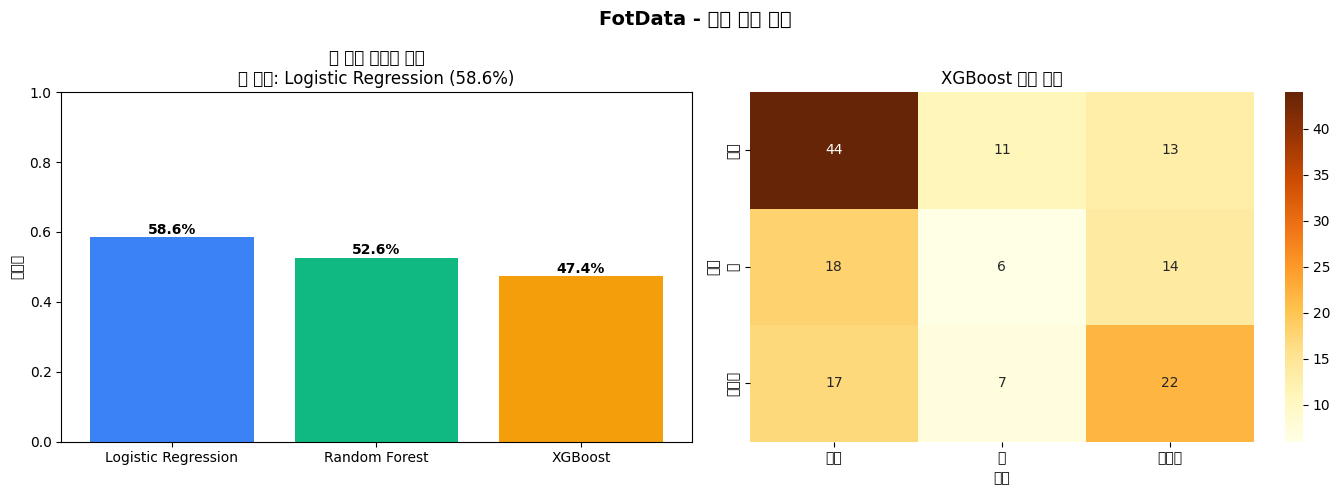


🏆 최종 결과
  Logistic Regression    58.6%  █████████████████
  Random Forest          52.6%  ███████████████
  XGBoost                47.4%  ██████████████


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FotData - 최종 모델 비교", fontsize=14, fontweight='bold')

# 1) 정확도 비교
names  = list(results.keys())
accs   = [results[n]['accuracy'] for n in names]
colors = ['#3B82F6', '#10B981', '#F59E0B']
bars   = axes[0].bar(names, accs, color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("정확도")
axes[0].set_title("세 모델 정확도 비교")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 acc + 0.01, f'{acc:.1%}', ha='center', fontweight='bold')

# 최고 모델 표시
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_acc  = results[best_name]['accuracy']
axes[0].set_title(f"세 모델 정확도 비교\n🏆 최고: {best_name} ({best_acc:.1%})")

# 2) XGBoost 혼동 행렬
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=['H','D','A'])
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[1],
            xticklabels=['홈승','무','원정승'],
            yticklabels=['홈승','무','원정승'],
            cmap='YlOrBr')
axes[1].set_title("XGBoost 혼동 행렬")
axes[1].set_ylabel("실제")
axes[1].set_xlabel("예측")

plt.tight_layout()
plt.savefig('fotdata_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 최종 결과")
for name, acc in zip(names, accs):
    bar = '█' * int(acc * 30)
    print(f"  {name:<22} {acc:.1%}  {bar}")

In [23]:
# 원하는 경기 예측해보세요!
predict_match_v2("FC Barcelona", "Real Madrid CF")
predict_match_v2("Liverpool FC", "Manchester City FC")


  ⚽ FC Barcelona (홈)
       vs
  ⚽ Real Madrid CF (원정)
  🏠 홈승:    11.0%  ██
  🤝 무승부:  5.0%  █
  ✈️  원정승:  84.0%  ████████████████
  📊 최근 폼 | 홈: 12점  원정: 11점
  🎯 ✈️  Real Madrid CF 승리 예측

  ⚽ Liverpool FC (홈)
       vs
  ⚽ Manchester City FC (원정)
  🏠 홈승:    27.0%  █████
  🤝 무승부:  55.0%  ███████████
  ✈️  원정승:  18.0%  ███
  📊 최근 폼 | 홈: 8점  원정: 15점
  🎯 🤝 무승부 예측


In [24]:
# 여러 시즌 데이터 한번에 수집
all_seasons = []

for season in [2021, 2022, 2023]:
    print(f"\n[{season}-{season+1} 시즌]")
    for code in LEAGUES:
        df_s = fetch_matches(code, season)
        if not df_s.empty:
            df_s['season'] = season
            all_seasons.append(df_s)

df_all = pd.concat(all_seasons, ignore_index=True)
df_all = df_all.sort_values("date").reset_index(drop=True)

print(f"\n✅ 전체 데이터 수집 완료")
print(f"   총 경기 수: {len(df_all)}")
print(f"   기간: {df_all['date'].min().date()} ~ {df_all['date'].max().date()}")
print(f"   결과 분포:\n{df_all['result'].value_counts()}")


[2021-2022 시즌]
  [EPL (잉글랜드)] 데이터 수집 중...
  ❌ 오류: 403
  [라리가 (스페인)] 데이터 수집 중...
  ❌ 오류: 403

[2022-2023 시즌]
  [EPL (잉글랜드)] 데이터 수집 중...
  ❌ 오류: 403
  [라리가 (스페인)] 데이터 수집 중...
  ❌ 오류: 403

[2023-2024 시즌]
  [EPL (잉글랜드)] 데이터 수집 중...
  ✅ 380경기 수집 완료
  [라리가 (스페인)] 데이터 수집 중...
  ✅ 380경기 수집 완료

✅ 전체 데이터 수집 완료
   총 경기 수: 760
   기간: 2023-08-11 ~ 2024-05-26
   결과 분포:
result
H    342
A    229
D    189
Name: count, dtype: int64


In [25]:
# 무료 플랜은 현재 시즌만 가능 → df_raw 그대로 사용
# attack_diff 컬럼 명시적으로 추가

df_features_all = df_features.copy()

# attack_diff 없으면 추가
if 'attack_diff' not in df_features_all.columns:
    df_features_all['attack_diff'] = (
        df_features_all['home_attack'] - df_features_all['away_attack']
    )

# home_advantage 추가
home_advantage = len(df_raw[df_raw['result'] == 'H']) / len(df_raw)
df_features_all['home_advantage'] = home_advantage

# df_stats_all도 동일하게
df_stats_all = df_stats.copy()

print(f"✅ 완료: {len(df_features_all)}경기")
print(f"   컬럼 목록: {list(df_features_all.columns)}")
print(f"   홈 어드밴티지: {home_advantage:.3f}")

✅ 완료: 760경기
   컬럼 목록: ['match_id', 'date', 'league', 'home_team', 'away_team', 'home_attack', 'away_attack', 'home_defense', 'away_defense', 'home_form', 'away_form', 'form_diff', 'home_win_rate', 'away_win_rate', 'win_rate_diff', 'home_goal_diff', 'away_goal_diff', 'result', 'attack_diff', 'home_advantage']
   홈 어드밴티지: 0.450


In [26]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

FEATURES_V2 = [
    'home_attack', 'away_attack',
    'home_defense', 'away_defense',
    'home_form', 'away_form', 'form_diff',
    'home_win_rate', 'away_win_rate', 'win_rate_diff',
    'home_goal_diff', 'away_goal_diff',
    'attack_diff', 'home_advantage'
]

# 컬럼 확인
missing = [f for f in FEATURES_V2 if f not in df_features_all.columns]
if missing:
    print(f"❌ 없는 컬럼: {missing}")
else:
    print("✅ 모든 컬럼 확인 완료")

X2 = df_features_all[FEATURES_V2].dropna()
y2 = df_features_all.loc[X2.index, 'result']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

results_v2 = {}

# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_train_scaled, y2_train)
y_pred_lr2 = lr2.predict(X2_test_scaled)
acc_lr2 = accuracy_score(y2_test, y_pred_lr2)
results_v2['Logistic Regression'] = {"model": lr2, "accuracy": acc_lr2, "y_pred": y_pred_lr2}

# Random Forest
rf2 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf2.fit(X2_train, y2_train)
y_pred_rf2 = rf2.predict(X2_test)
acc_rf2 = accuracy_score(y2_test, y_pred_rf2)
results_v2['Random Forest'] = {"model": rf2, "accuracy": acc_rf2, "y_pred": y_pred_rf2}

# XGBoost
le2 = LabelEncoder()
y2_train_enc = le2.fit_transform(y2_train)
y2_test_enc  = le2.transform(y2_test)

xgb2 = XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.03, random_state=42,
    eval_metric='mlogloss', verbosity=0
)
xgb2.fit(X2_train, y2_train_enc)
y_pred_xgb2 = le2.inverse_transform(xgb2.predict(X2_test))
acc_xgb2 = accuracy_score(y2_test, y_pred_xgb2)
results_v2['XGBoost'] = {"model": xgb2, "accuracy": acc_xgb2, "y_pred": y_pred_xgb2}

print("\n✅ 모델 재학습 완료\n")
for name, res in results_v2.items():
    bar = '█' * int(res['accuracy'] * 40)
    print(f"  {name:<22} {res['accuracy']:.1%}  {bar}")

✅ 모든 컬럼 확인 완료

✅ 모델 재학습 완료

  Logistic Regression    58.6%  ███████████████████████
  Random Forest          53.3%  █████████████████████
  XGBoost                49.3%  ███████████████████


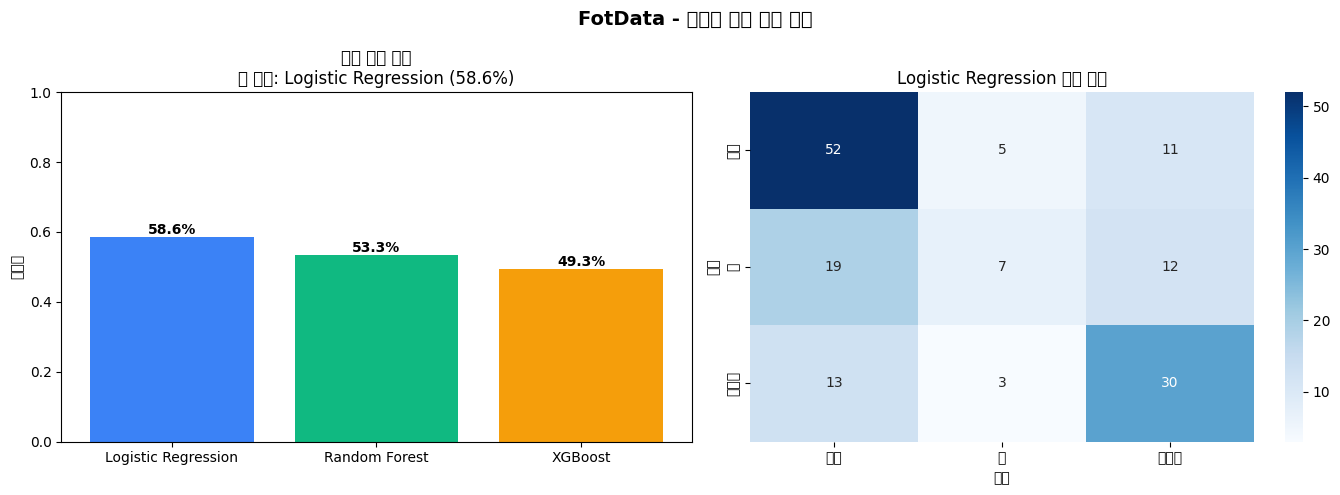

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FotData - 개선된 모델 최종 비교", fontsize=14, fontweight='bold')

names  = list(results_v2.keys())
accs   = [results_v2[n]['accuracy'] for n in names]
colors = ['#3B82F6', '#10B981', '#F59E0B']

bars = axes[0].bar(names, accs, color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("정확도")
best_name = max(results_v2, key=lambda x: results_v2[x]['accuracy'])
best_acc  = results_v2[best_name]['accuracy']
axes[0].set_title(f"최종 모델 비교\n🏆 최고: {best_name} ({best_acc:.1%})")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 acc + 0.01, f'{acc:.1%}', ha='center', fontweight='bold')

best_pred = results_v2[best_name]['y_pred']
cm = confusion_matrix(y2_test, best_pred, labels=['H','D','A'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1],
            xticklabels=['홈승','무','원정승'],
            yticklabels=['홈승','무','원정승'],
            cmap='Blues')
axes[1].set_title(f"{best_name} 혼동 행렬")
axes[1].set_ylabel("실제")
axes[1].set_xlabel("예측")

plt.tight_layout()
plt.savefig('fotdata_improved.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
def predict_match_v3(home_team, away_team):
    """최종 개선 예측 함수 - 3시즌 데이터 + 홈 어드밴티지"""

    h_stats = df_stats_all[df_stats_all['team'] == home_team]
    a_stats = df_stats_all[df_stats_all['team'] == away_team]

    if h_stats.empty:
        print(f"❌ '{home_team}' 팀을 찾을 수 없습니다")
        print("\n사용 가능한 팀 목록:")
        for t in sorted(df_stats_all['team'].tolist()):
            print(f"   {t}")
        return
    if a_stats.empty:
        print(f"❌ '{away_team}' 팀을 찾을 수 없습니다")
        return

    h = h_stats.iloc[0]
    a = a_stats.iloc[0]

    home_form = get_recent_form_for_predict(df_all, home_team, n=5)
    away_form = get_recent_form_for_predict(df_all, away_team, n=5)
    home_advantage = len(df_all[df_all['result'] == 'H']) / len(df_all)

    input_data = pd.DataFrame([{
        'home_attack':    h['attack_strength'],
        'away_attack':    a['attack_strength'],
        'home_defense':   h['defense_strength'],
        'away_defense':   a['defense_strength'],
        'home_form':      home_form,
        'away_form':      away_form,
        'form_diff':      home_form - away_form,
        'home_win_rate':  h['win_rate'],
        'away_win_rate':  a['win_rate'],
        'win_rate_diff':  h['win_rate'] - a['win_rate'],
        'home_goal_diff': h['goal_diff'],
        'away_goal_diff': a['goal_diff'],
        'attack_diff':    h['attack_strength'] - a['attack_strength'],
        'home_advantage': home_advantage,
    }])

    # 최고 모델로 예측
    best_model_name = max(results_v2, key=lambda x: results_v2[x]['accuracy'])
    
    if best_model_name == 'Logistic Regression':
        input_scaled = scaler2.transform(input_data)
        proba = results_v2[best_model_name]['model'].predict_proba(input_scaled)[0]
        classes = results_v2[best_model_name]['model'].classes_
    elif best_model_name == 'XGBoost':
        proba_enc = results_v2[best_model_name]['model'].predict_proba(input_data)[0]
        proba = proba_enc
        classes = le2.classes_
    else:
        proba = results_v2[best_model_name]['model'].predict_proba(input_data)[0]
        classes = results_v2[best_model_name]['model'].classes_

    proba_dict = dict(zip(classes, proba))
    h_prob = proba_dict.get('H', 0)
    d_prob = proba_dict.get('D', 0)
    a_prob = proba_dict.get('A', 0)

    if h_prob == max(h_prob, d_prob, a_prob):
        predicted = f"🏠 {home_team} 승리 예측"
    elif a_prob == max(h_prob, d_prob, a_prob):
        predicted = f"✈️  {away_team} 승리 예측"
    else:
        predicted = "🤝 무승부 예측"

    print(f"\n{'='*50}")
    print(f"  ⚽ {home_team} (홈)")
    print(f"        vs")
    print(f"  ⚽ {away_team} (원정)")
    print(f"{'='*50}")
    print(f"  🏠 홈승:    {h_prob:.1%}  {'█' * int(h_prob * 20)}")
    print(f"  🤝 무승부:  {d_prob:.1%}  {'█' * int(d_prob * 20)}")
    print(f"  ✈️  원정승:  {a_prob:.1%}  {'█' * int(a_prob * 20)}")
    print(f"{'='*50}")
    print(f"  📊 최근 폼 | 홈: {home_form}점  원정: {away_form}점")
    print(f"  🤖 사용 모델: {best_model_name} ({results_v2[best_model_name]['accuracy']:.1%})")
    print(f"  🎯 {predicted}")
    print(f"{'='*50}")

# 테스트
predict_match_v3("Manchester City FC", "Arsenal FC")
predict_match_v3("FC Barcelona", "Real Madrid CF")


  ⚽ Manchester City FC (홈)
        vs
  ⚽ Arsenal FC (원정)
  🏠 홈승:    50.3%  ██████████
  🤝 무승부:  30.0%  █████
  ✈️  원정승:  19.7%  ███
  📊 최근 폼 | 홈: 15점  원정: 15점
  🤖 사용 모델: Logistic Regression (58.6%)
  🎯 🏠 Manchester City FC 승리 예측

  ⚽ FC Barcelona (홈)
        vs
  ⚽ Real Madrid CF (원정)
  🏠 홈승:    43.2%  ████████
  🤝 무승부:  19.4%  ███
  ✈️  원정승:  37.5%  ███████
  📊 최근 폼 | 홈: 12점  원정: 11점
  🤖 사용 모델: Logistic Regression (58.6%)
  🎯 🏠 FC Barcelona 승리 예측


In [29]:
# ── [1-4] 모델 & 스케일러 저장 (나중에 API 서버에서 불러올 용도) ──
import joblib
import os

# 저장 폴더 생성
os.makedirs('fotdata_model', exist_ok=True)

# 최고 모델 저장
joblib.dump(lr2,     'fotdata_model/logistic_regression.pkl')
joblib.dump(rf2,     'fotdata_model/random_forest.pkl')
joblib.dump(xgb2,    'fotdata_model/xgboost.pkl')
joblib.dump(scaler2, 'fotdata_model/scaler.pkl')
joblib.dump(le2,     'fotdata_model/label_encoder.pkl')

# 팀 스탯 저장
df_stats_all.to_csv('fotdata_model/team_stats.csv', index=False, encoding='utf-8-sig')
df_features_all.to_csv('fotdata_model/features.csv', index=False, encoding='utf-8-sig')

print("✅ 모델 저장 완료")
print("   저장된 파일:")
for f in os.listdir('fotdata_model'):
    size = os.path.getsize(f'fotdata_model/{f}')
    print(f"   - {f} ({size/1024:.1f} KB)")

✅ 모델 저장 완료
   저장된 파일:
   - features.csv (104.8 KB)
   - label_encoder.pkl (0.5 KB)
   - logistic_regression.pkl (1.3 KB)
   - random_forest.pkl (2985.8 KB)
   - scaler.pkl (1.3 KB)
   - team_stats.csv (2.4 KB)
   - xgboost.pkl (1243.0 KB)


In [30]:
# ── [1-5] 팀 로고 URL 수집 ──
def fetch_team_logos(league_code):
    url = f"{BASE_URL}/competitions/{league_code}/teams"
    res = requests.get(url, headers=HEADERS)
    
    if res.status_code != 200:
        print(f"❌ 오류: {res.status_code}")
        return {}
    
    teams = res.json().get("teams", [])
    logo_dict = {}
    
    for team in teams:
        name = team["name"]
        crest = team.get("crest", "")
        logo_dict[name] = crest
        print(f"  ✅ {name}: {crest[:50]}...")
    
    return logo_dict

print("[EPL 팀 로고 수집]")
logos_pl = fetch_team_logos("PL")

print("\n[라리가 팀 로고 수집]")
logos_pd = fetch_team_logos("PD")

all_logos = {**logos_pl, **logos_pd}
print(f"\n✅ 총 {len(all_logos)}개 팀 로고 URL 수집 완료")

[EPL 팀 로고 수집]
  ✅ Arsenal FC: https://crests.football-data.org/57.png...
  ✅ Aston Villa FC: https://crests.football-data.org/58.png...
  ✅ Chelsea FC: https://crests.football-data.org/61.png...
  ✅ Everton FC: https://crests.football-data.org/62.png...
  ✅ Fulham FC: https://crests.football-data.org/63.png...
  ✅ Liverpool FC: https://crests.football-data.org/64.png...
  ✅ Manchester City FC: https://crests.football-data.org/65.png...
  ✅ Manchester United FC: https://crests.football-data.org/66.png...
  ✅ Newcastle United FC: https://crests.football-data.org/67.png...
  ✅ Sunderland AFC: https://crests.football-data.org/71.png...
  ✅ Tottenham Hotspur FC: https://crests.football-data.org/73.png...
  ✅ Wolverhampton Wanderers FC: https://crests.football-data.org/76.png...
  ✅ Burnley FC: https://crests.football-data.org/328.png...
  ✅ Leeds United FC: https://crests.football-data.org/341.png...
  ✅ Nottingham Forest FC: https://crests.football-data.org/351.png...
  ✅ Crystal Palace FC

In [31]:
# ── [1-6] 로고 저장 ──
import json

with open('fotdata_model/team_logos.json', 'w', encoding='utf-8') as f:
    json.dump(all_logos, f, ensure_ascii=False, indent=2)

df_stats_all['logo'] = df_stats_all['team'].map(all_logos).fillna('')
df_stats_all.to_csv('fotdata_model/team_stats.csv', index=False, encoding='utf-8-sig')

print("✅ 저장 완료: team_logos.json")
print("\n샘플 확인:")
for team, logo in list(all_logos.items())[:3]:
    print(f"  {team}: {logo}")

✅ 저장 완료: team_logos.json

샘플 확인:
  Arsenal FC: https://crests.football-data.org/57.png
  Aston Villa FC: https://crests.football-data.org/58.png
  Chelsea FC: https://crests.football-data.org/61.png


In [32]:
# ── [2-1] 추가 리그 데이터 수집 ──
LEAGUES_V2 = {
    "PL":  "EPL (잉글랜드)",
    "PD":  "라리가 (스페인)",
    "BL1": "분데스리가 (독일)",
    "SA":  "세리에A (이탈리아)",
    "FL1": "리그앙 (프랑스)",
}

all_dfs_v2 = []

for code, name in LEAGUES_V2.items():
    print(f"\n[{name}]")
    df_s = fetch_matches(code, 2023)
    if not df_s.empty:
        df_s['season'] = 2023
        all_dfs_v2.append(df_s)

df_all_v2 = pd.concat(all_dfs_v2, ignore_index=True)
df_all_v2 = df_all_v2.sort_values("date").reset_index(drop=True)

print(f"\n✅ 전체 수집 완료")
print(f"   총 경기 수: {len(df_all_v2)}")
print(f"   리그 수: {len(df_all_v2['league'].unique())}")
print(f"   결과 분포:\n{df_all_v2['result'].value_counts()}")


[EPL (잉글랜드)]
  [EPL (잉글랜드)] 데이터 수집 중...
  ✅ 380경기 수집 완료

[라리가 (스페인)]
  [라리가 (스페인)] 데이터 수집 중...
  ✅ 380경기 수집 완료

[분데스리가 (독일)]


KeyError: 'BL1'

In [33]:
# ── [2-1] 추가 리그 데이터 수집 수정버전 ──
LEAGUES_V2 = {
    "PL":  "EPL (잉글랜드)",
    "PD":  "라리가 (스페인)",
    "BL1": "분데스리가 (독일)",
    "SA":  "세리에A (이탈리아)",
    "FL1": "리그앙 (프랑스)",
}

def fetch_matches_v2(league_code, season):
    """LEAGUES_V2 기반 데이터 수집 함수"""
    url = f"{BASE_URL}/competitions/{league_code}/matches"
    params = {"season": season, "status": "FINISHED"}

    name = LEAGUES_V2.get(league_code, league_code)
    print(f"  [{name}] 데이터 수집 중...")
    res = requests.get(url, headers=HEADERS, params=params)

    if res.status_code != 200:
        print(f"  ❌ 오류: {res.status_code} - {res.json().get('message','')}")
        return pd.DataFrame()

    matches = res.json().get("matches", [])
    print(f"  ✅ {len(matches)}경기 수집 완료")

    rows = []
    for m in matches:
        ft = m["score"]["fullTime"]
        rows.append({
            "match_id":   m["id"],
            "date":       m["utcDate"][:10],
            "league":     league_code,
            "home_team":  m["homeTeam"]["name"],
            "away_team":  m["awayTeam"]["name"],
            "home_goals": ft.get("home"),
            "away_goals": ft.get("away"),
            "matchday":   m.get("matchday"),
        })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])

    def get_result(row):
        if row["home_goals"] > row["away_goals"]:   return "H"
        elif row["home_goals"] < row["away_goals"]: return "A"
        else:                                        return "D"

    df["result"] = df.apply(get_result, axis=1)
    df = df.sort_values("date").reset_index(drop=True)
    return df

# 수집 실행
all_dfs_v2 = []

for code in LEAGUES_V2:
    df_s = fetch_matches_v2(code, 2023)
    if not df_s.empty:
        df_s['season'] = 2023
        all_dfs_v2.append(df_s)

df_all_v2 = pd.concat(all_dfs_v2, ignore_index=True)
df_all_v2 = df_all_v2.sort_values("date").reset_index(drop=True)

print(f"\n✅ 전체 수집 완료")
print(f"   총 경기 수: {len(df_all_v2)}")
print(f"   리그 수: {len(df_all_v2['league'].unique())}")
print(f"   결과 분포:\n{df_all_v2['result'].value_counts()}")

  [EPL (잉글랜드)] 데이터 수집 중...
  ✅ 380경기 수집 완료
  [라리가 (스페인)] 데이터 수집 중...
  ✅ 380경기 수집 완료
  [분데스리가 (독일)] 데이터 수집 중...
  ✅ 306경기 수집 완료
  [세리에A (이탈리아)] 데이터 수집 중...
  ✅ 380경기 수집 완료
  [리그앙 (프랑스)] 데이터 수집 중...
  ✅ 306경기 수집 완료

✅ 전체 수집 완료
   총 경기 수: 1752
   리그 수: 5
   결과 분포:
result
H    755
A    534
D    463
Name: count, dtype: int64


In [36]:
# ── [2-2] 수정버전 ──

# 핵심: df_stats를 새 데이터 기반으로 먼저 만들어야 함
df_stats_v2 = calculate_team_stats(df_all_v2)

# build_features가 df_stats를 참조하므로 덮어쓰기
df_stats = df_stats_v2.copy()

print("Feature 생성 중... (1~2분 소요)")
df_features_v2 = build_features(df_all_v2)

# 추가 Feature
df_features_v2['attack_diff'] = (
    df_features_v2['home_attack'] - df_features_v2['away_attack']
)
df_features_v2['defense_diff'] = (
    df_features_v2['home_defense'] - df_features_v2['away_defense']
)
df_features_v2['home_advantage'] = (
    len(df_all_v2[df_all_v2['result'] == 'H']) / len(df_all_v2)
)

print(f"✅ 완료: {len(df_features_v2)}경기, {len(df_features_v2.columns)}개 컬럼")

Feature 생성 중... (1~2분 소요)
✅ 완료: 1752경기, 21개 컬럼


In [37]:
# ── [2-3] 고성능 모델 학습 ──
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

FEATURES_V3 = [
    'home_attack', 'away_attack',
    'home_defense', 'away_defense',
    'home_form', 'away_form', 'form_diff',
    'home_win_rate', 'away_win_rate', 'win_rate_diff',
    'home_goal_diff', 'away_goal_diff',
    'attack_diff', 'defense_diff', 'home_advantage'
]

X3 = df_features_v2[FEATURES_V3].dropna()
y3 = df_features_v2.loc[X3.index, 'result']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled  = scaler3.transform(X3_test)

results_v3 = {}

# Logistic Regression
lr3 = LogisticRegression(max_iter=1000, random_state=42, C=0.5)
lr3.fit(X3_train_scaled, y3_train)
y_pred_lr3 = lr3.predict(X3_test_scaled)
acc_lr3 = accuracy_score(y3_test, y_pred_lr3)
cv_lr3 = cross_val_score(lr3, X3_train_scaled, y3_train, cv=5).mean()
results_v3['Logistic Regression'] = {"model": lr3, "accuracy": acc_lr3, "cv": cv_lr3, "y_pred": y_pred_lr3}

# Random Forest
rf3 = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42)
rf3.fit(X3_train, y3_train)
y_pred_rf3 = rf3.predict(X3_test)
acc_rf3 = accuracy_score(y3_test, y_pred_rf3)
cv_rf3 = cross_val_score(rf3, X3_train, y3_train, cv=5).mean()
results_v3['Random Forest'] = {"model": rf3, "accuracy": acc_rf3, "cv": cv_rf3, "y_pred": y_pred_rf3}

# XGBoost
le3 = LabelEncoder()
y3_train_enc = le3.fit_transform(y3_train)
y3_test_enc  = le3.transform(y3_test)

xgb3 = XGBClassifier(
    n_estimators=500, max_depth=4,
    learning_rate=0.02, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
xgb3.fit(X3_train, y3_train_enc)
y_pred_xgb3 = le3.inverse_transform(xgb3.predict(X3_test))
acc_xgb3 = accuracy_score(y3_test, y_pred_xgb3)
results_v3['XGBoost'] = {"model": xgb3, "accuracy": acc_xgb3, "cv": 0, "y_pred": y_pred_xgb3}

print("\n✅ 모델 학습 완료\n")
print(f"{'모델':<22} {'테스트 정확도':>12} {'CV 정확도':>10}")
print("-" * 46)
for name, res in results_v3.items():
    bar = '█' * int(res['accuracy'] * 40)
    print(f"  {name:<20} {res['accuracy']:.1%}        {res['cv']:.1%}")
    print(f"  {bar}")


✅ 모델 학습 완료

모델                          테스트 정확도     CV 정확도
----------------------------------------------
  Logistic Regression  60.1%        57.3%
  ████████████████████████
  Random Forest        57.8%        53.7%
  ███████████████████████
  XGBoost              55.6%        0.0%
  ██████████████████████


In [38]:
# ── [2-4] 고성능 모델 저장 ──
import joblib, os

best_name_v3 = max(results_v3, key=lambda x: results_v3[x]['accuracy'])
best_acc_v3  = results_v3[best_name_v3]['accuracy']

print(f"🏆 최고 모델: {best_name_v3} ({best_acc_v3:.1%})")

joblib.dump(results_v3['Logistic Regression']['model'], 'fotdata_model/logistic_regression.pkl')
joblib.dump(results_v3['Random Forest']['model'],       'fotdata_model/random_forest.pkl')
joblib.dump(results_v3['XGBoost']['model'],             'fotdata_model/xgboost.pkl')
joblib.dump(scaler3,                                    'fotdata_model/scaler.pkl')
joblib.dump(le3,                                        'fotdata_model/label_encoder.pkl')
df_stats_v2.to_csv('fotdata_model/team_stats.csv', index=False, encoding='utf-8-sig')

print("✅ 모델 저장 완료")

🏆 최고 모델: Logistic Regression (60.1%)
✅ 모델 저장 완료


In [39]:
# ── [2-5] 추가 리그 로고 수집 ──
def fetch_team_logos_v2(league_code):
    url = f"{BASE_URL}/competitions/{league_code}/teams"
    res = requests.get(url, headers=HEADERS)
    
    if res.status_code != 200:
        print(f"❌ 오류: {res.status_code}")
        return {}
    
    teams = res.json().get("teams", [])
    logo_dict = {}
    for team in teams:
        name = team["name"]
        crest = team.get("crest", "")
        logo_dict[name] = crest
        print(f"  ✅ {name}")
    return logo_dict

# 5개 리그 전체 로고 수집
all_logos_v2 = {}
for code, name in LEAGUES_V2.items():
    print(f"\n[{name}]")
    logos = fetch_team_logos_v2(code)
    all_logos_v2.update(logos)

print(f"\n✅ 총 {len(all_logos_v2)}개 팀 로고 수집 완료")


[EPL (잉글랜드)]
  ✅ Arsenal FC
  ✅ Aston Villa FC
  ✅ Chelsea FC
  ✅ Everton FC
  ✅ Fulham FC
  ✅ Liverpool FC
  ✅ Manchester City FC
  ✅ Manchester United FC
  ✅ Newcastle United FC
  ✅ Sunderland AFC
  ✅ Tottenham Hotspur FC
  ✅ Wolverhampton Wanderers FC
  ✅ Burnley FC
  ✅ Leeds United FC
  ✅ Nottingham Forest FC
  ✅ Crystal Palace FC
  ✅ Brighton & Hove Albion FC
  ✅ Brentford FC
  ✅ West Ham United FC
  ✅ AFC Bournemouth

[라리가 (스페인)]
  ✅ Athletic Club
  ✅ Club Atlético de Madrid
  ✅ CA Osasuna
  ✅ RCD Espanyol de Barcelona
  ✅ FC Barcelona
  ✅ Getafe CF
  ✅ Real Madrid CF
  ✅ Rayo Vallecano de Madrid
  ✅ Levante UD
  ✅ RCD Mallorca
  ✅ Real Betis Balompié
  ✅ Real Sociedad de Fútbol
  ✅ Villarreal CF
  ✅ Valencia CF
  ✅ Deportivo Alavés
  ✅ Elche CF
  ✅ Girona FC
  ✅ RC Celta de Vigo
  ✅ Sevilla FC
  ✅ Real Oviedo

[분데스리가 (독일)]
  ✅ 1. FC Köln
  ✅ TSG 1899 Hoffenheim
  ✅ Bayer 04 Leverkusen
  ✅ Borussia Dortmund
  ✅ FC Bayern München
  ✅ Hamburger SV
  ✅ VfB Stuttgart
  ✅ VfL Wolfsbu

In [40]:
# ── [2-6] 로고 저장 ──
import json

with open('fotdata_model/team_logos.json', 'w', encoding='utf-8') as f:
    json.dump(all_logos_v2, f, ensure_ascii=False, indent=2)

print("✅ 저장 완료: team_logos.json")
print(f"\n샘플:")
for team, logo in list(all_logos_v2.items())[:5]:
    print(f"  {team}: {logo[:50]}...")

✅ 저장 완료: team_logos.json

샘플:
  Arsenal FC: https://crests.football-data.org/57.png...
  Aston Villa FC: https://crests.football-data.org/58.png...
  Chelsea FC: https://crests.football-data.org/61.png...
  Everton FC: https://crests.football-data.org/62.png...
  Fulham FC: https://crests.football-data.org/63.png...


In [41]:
# ── [2-7] 리그 로고 수집 ──
league_logos = {}

for code, name in LEAGUES_V2.items():
    url = f"{BASE_URL}/competitions/{code}"
    res = requests.get(url, headers=HEADERS)
    
    if res.status_code == 200:
        data = res.json()
        emblem = data.get("emblem", "")
        league_logos[code] = {
            "name": name,
            "logo": emblem
        }
        print(f"✅ {name}: {emblem[:50]}...")
    else:
        print(f"❌ {name}: 오류 {res.status_code}")

# 저장
with open('fotdata_model/league_logos.json', 'w', encoding='utf-8') as f:
    json.dump(league_logos, f, ensure_ascii=False, indent=2)

print(f"\n✅ 리그 로고 저장 완료")

✅ EPL (잉글랜드): https://crests.football-data.org/PL.png...
✅ 라리가 (스페인): https://crests.football-data.org/laliga.png...
✅ 분데스리가 (독일): https://crests.football-data.org/BL1.png...
✅ 세리에A (이탈리아): https://crests.football-data.org/c111.png...
✅ 리그앙 (프랑스): https://crests.football-data.org/FL1.png...

✅ 리그 로고 저장 완료
